In [1]:
import tqdm
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
from constants import MsiIntensityNormalization, DecompositionMethod, MsiIonMode

## Constant Definitions

In [2]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/p_PDA/d_C1"
MODALITY_NAME = "MSI"
SAMPLE_ID_LIST = [
    "PDAC001T1",
    "PDAC001T2",
    "PDAC002N0",
    "PDAC002T1",
    "PDAC002T2",
    "PDAC003N0",
    "PDAC003T0",
    "PDAC004N0",
    "PDAC007N0",
    "PDAC007T1",
    "PDAC007T2",
    #"PDAC010N0",
    "PDAC010T0",
    "PDAC011N0",
    "PDAC011T0",
]

MERGED_DATASET_PATH = os.path.join(PATH, "merged", "preprocessing", f"{MODALITY_NAME}_merged.h5ad")

In [25]:
from sklearn.decomposition import PCA, NMF

def visualize_spatial(clusters: np.ndarray, raster_coords: np.ndarray, cluster_colors: np.ndarray, title: str):
	'''
	Visualize the raster image of one sample, coloring each raster block (data spot) according to its cluster assignment.
	
	Parameters
	----------
	clusters : np.ndarray
		Array of shape (n_spots,) containing the cluster assignment for each data spot.
	raster_coords : np.ndarray
		Array of shape (n_spots, 2, 2) containing the raster coordinates for each data spot.
	cluster_colors : np.ndarray
		Array of shape (n_clusters,) containing the hex color code for each cluster.
	title : str
		Title for the plot.
	
	'''

	# Convert the list of cluster colors into a list of RGB values
	cluster_colors_rgb = {}
	for index in range(len(cluster_colors)):
		cluster_colors_rgb[str(index)] = tuple(int(cluster_colors[index][i:i+2], 16) for i in (1, 3, 5))

	# Generate a raster image based on the raster coordinates and cluster colors
	img = np.zeros((raster_coords[:,:,1].max()+1, raster_coords[:,:,0].max()+1, 3), dtype=np.uint8)
	for index, ((x1, y1), (x2, y2)) in enumerate(raster_coords):
		img[y1:y2, x1:x2] = cluster_colors_rgb[clusters[index]]

	# Add 30 pixel padding around the image
	pad_width = 30
	img = np.pad(img, ((pad_width, pad_width), (pad_width, pad_width), (0, 0)), mode='constant', constant_values=0)

	# Display the image
	plt.figure(figsize=(15,15))
	plt.imshow(img, cmap='gray')
	plt.title(title)
	plt.show()


## MSI Dataset preparation and processing

In [ ]:
samples: list[lipidomics.MsiSample] = []

# Load each MSI sample and unify POS and NEG ion coordinates
for SAMPLE_ID in tqdm.tqdm(SAMPLE_ID_LIST, desc="Preparing MSI samples", unit="sample"):
    msi_sample = lipidomics.MsiSample(
        source_path = PATH,
        sample_id=SAMPLE_ID,
        modality_name=MODALITY_NAME,
        double_ion_mode=True
    )
    samples.append(msi_sample)

Preparing MSI samples: 100%|██████████| 14/14 [01:09<00:00,  4.99s/sample]


In [16]:
# Create an MSI dataset from the samples
msi_dataset = lipidomics.MsiDataset(samples)

In [17]:
msi_dataset.process_dataset(intensity_normalization=MsiIntensityNormalization.TIC)

Aligning intensities to reference M/Z: 100%|██████████| 14/14 [06:09<00:00, 26.41s/sample]


In [ ]:
adatas: list[ad.AnnData] = []

for sample in tqdm.tqdm(samples, desc="Merging MSI samples into AnnData", unit="sample"):
    sample_adata = ad.read_h5ad(os.path.join(sample.output_path, f"{sample.sample_id}_{MODALITY_NAME}_processed.h5ad"))

    # Update the obs_names to include the sample ID for uniqueness
    sample_adata.obs_names = [f"{sample.sample_id}_{obs_name}" for obs_name in sample_adata.obs_names]
    adatas.append(sample_adata)

# Concatenate all the AnnData objects, ensuring unique obs_names (indexes)
if adatas:
    msi_adata = ad.concat(adatas)

    # Add the var informations
    msi_adata.var = adatas[0].var.copy()

# Save the combined AnnData

if not os.path.exists(os.path.dirname(MERGED_DATASET_PATH)):
    os.makedirs(os.path.dirname(MERGED_DATASET_PATH))
msi_adata.write_h5ad(MERGED_DATASET_PATH)


Merging MSI samples into AnnData: 100%|██████████| 14/14 [00:06<00:00,  2.21sample/s]


## Dataset Visualization

In [4]:
# Load the merged dataset
msi_dataset = ad.read_h5ad(MERGED_DATASET_PATH)

In [5]:
# Compute PCA and UMAP visualizations
sc.pp.pca(msi_dataset, n_comps=50, layer='X_tic')
sc.pp.neighbors(msi_dataset)
sc.tl.umap(msi_dataset)

/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


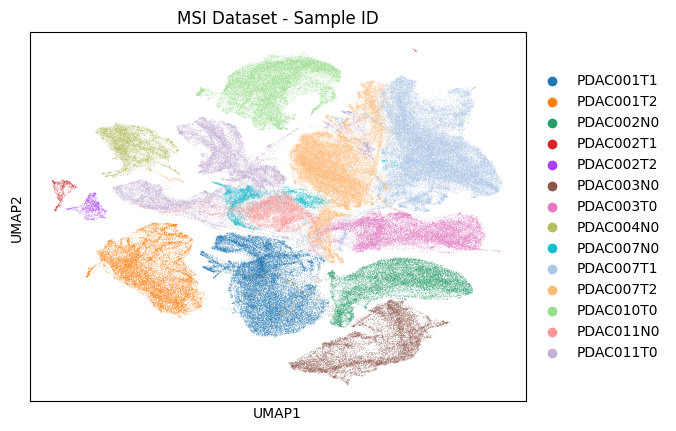

In [6]:
# Visualize the dataset
sc.pl.umap(msi_dataset, color=['batch_id'], title="MSI Dataset - Sample ID")

In [7]:
# Perform Batch correction using Harmony
import scanpy.external as sce
msi_dataset.layers['raw'] = msi_dataset.X.copy()
msi_dataset.X = msi_dataset.layers['X_tic'].copy()

sce.pp.harmony_integrate(msi_dataset, key='batch_id')

2025-11-05 10:07:36,498 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-05 10:07:43,078 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-05 10:07:43,466 - harmonypy - INFO - Iteration 1 of 10
2025-11-05 10:08:27,613 - harmonypy - INFO - Iteration 2 of 10
2025-11-05 10:09:12,839 - harmonypy - INFO - Iteration 3 of 10
2025-11-05 10:09:56,893 - harmonypy - INFO - Converged after 3 iterations


In [8]:
# Compute PCA and UMAP visualizations
sc.pp.neighbors(msi_dataset, use_rep='X_pca_harmony')
sc.tl.umap(msi_dataset)

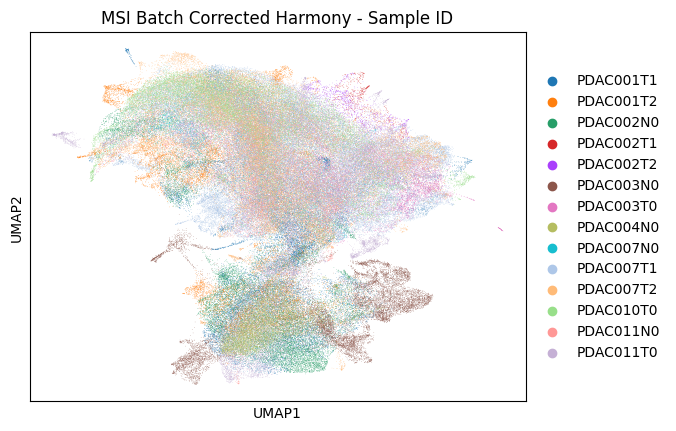

In [9]:
sc.pl.umap(msi_dataset, color=['batch_id'], title="MSI Batch Corrected Harmony - Sample ID")

In [29]:
# Leiden clustering on the Harmony-corrected data
sc.tl.leiden(msi_dataset, resolution=0.5, flavor='igraph')

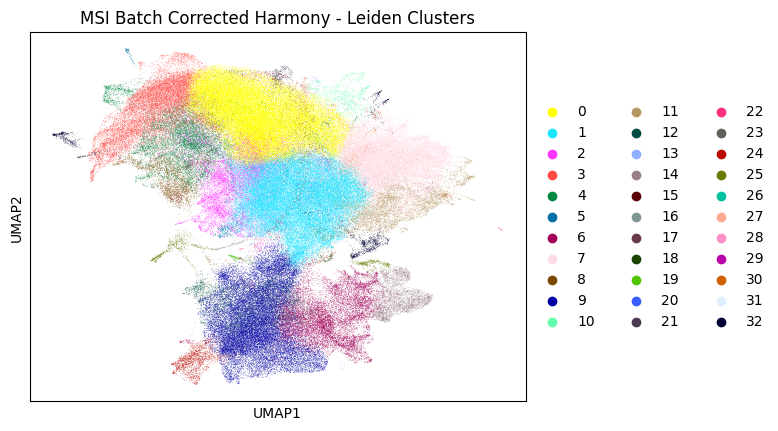

In [30]:
sc.pl.umap(msi_dataset, color=['leiden'], title="MSI Batch Corrected Harmony - Leiden Clusters")

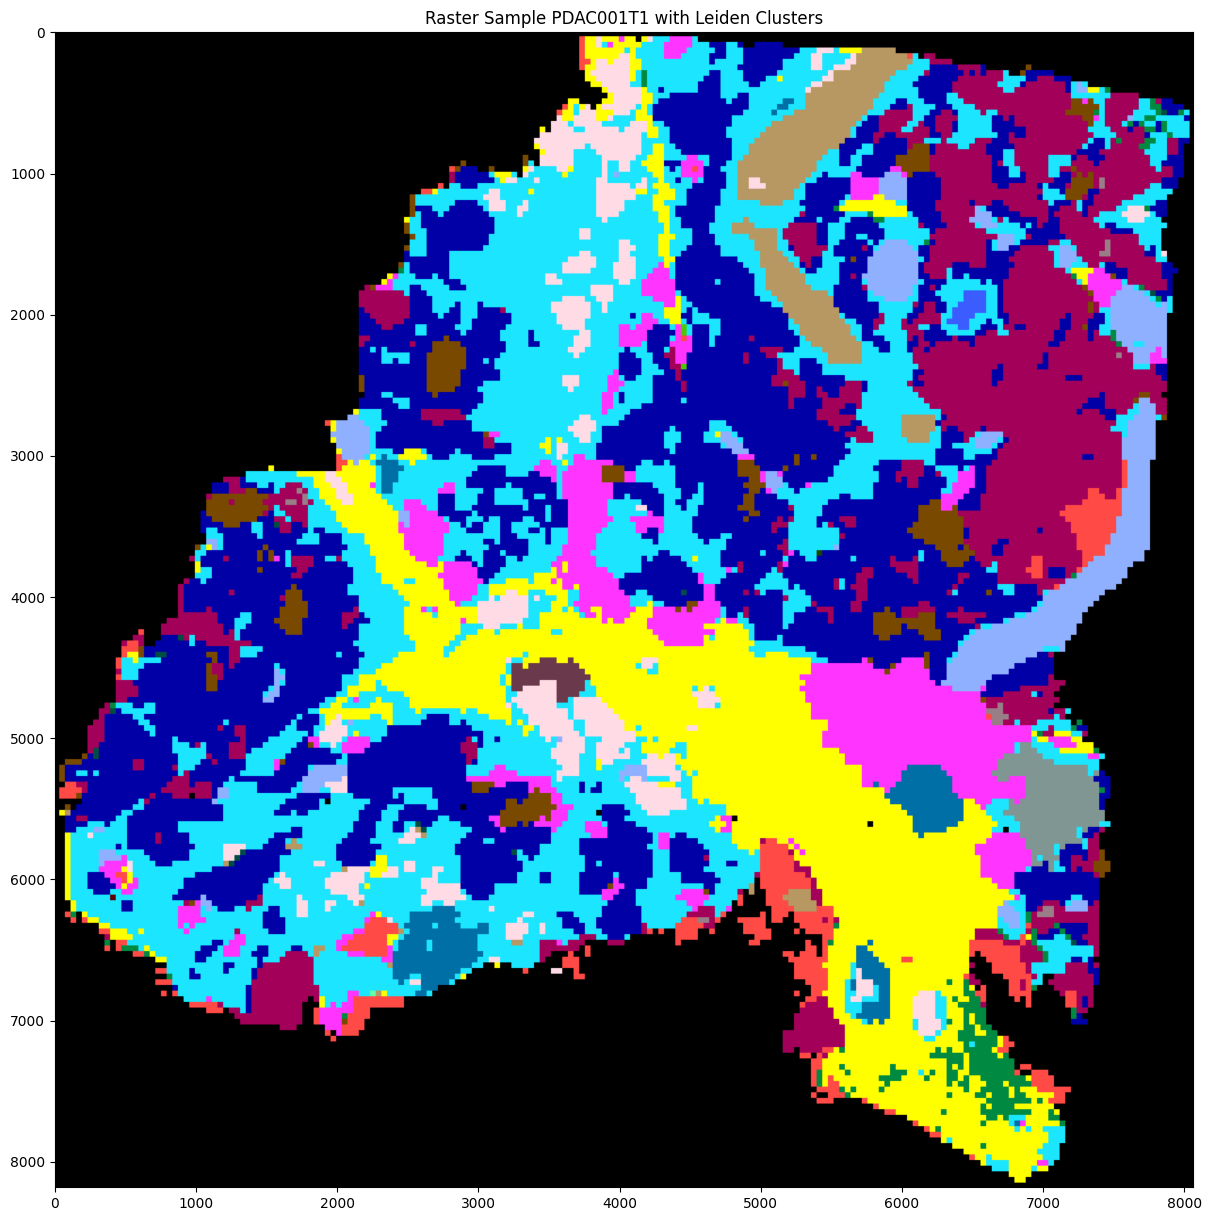

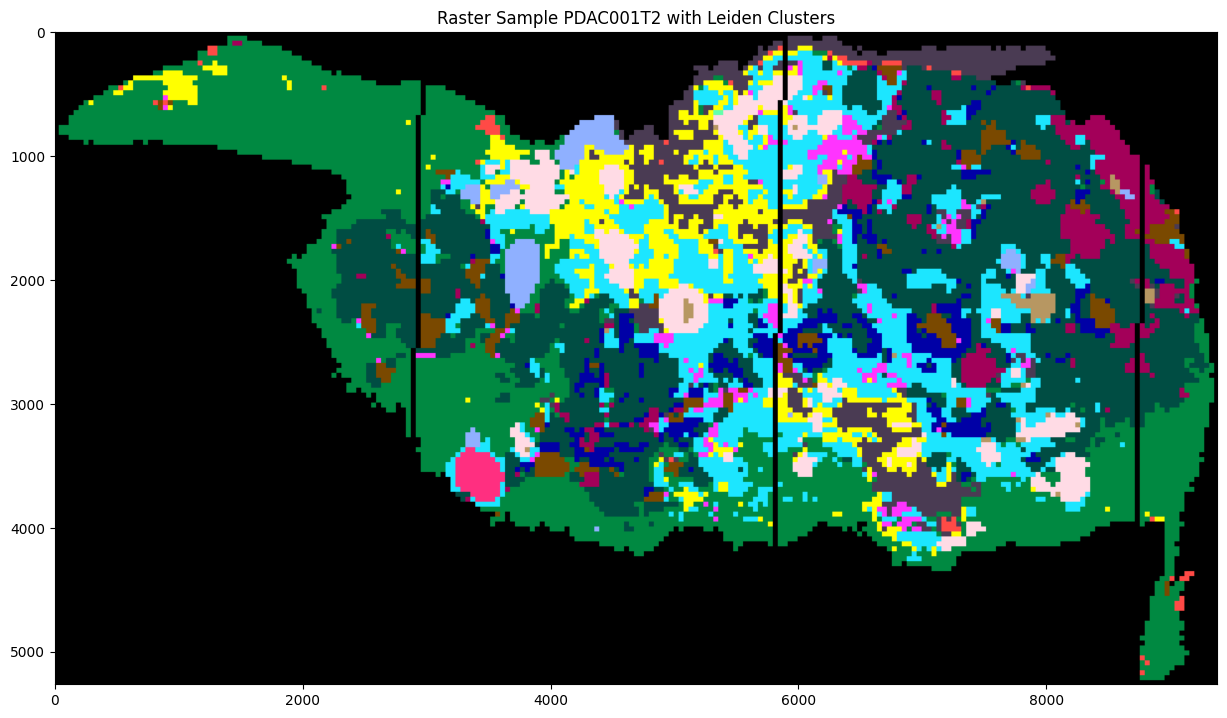

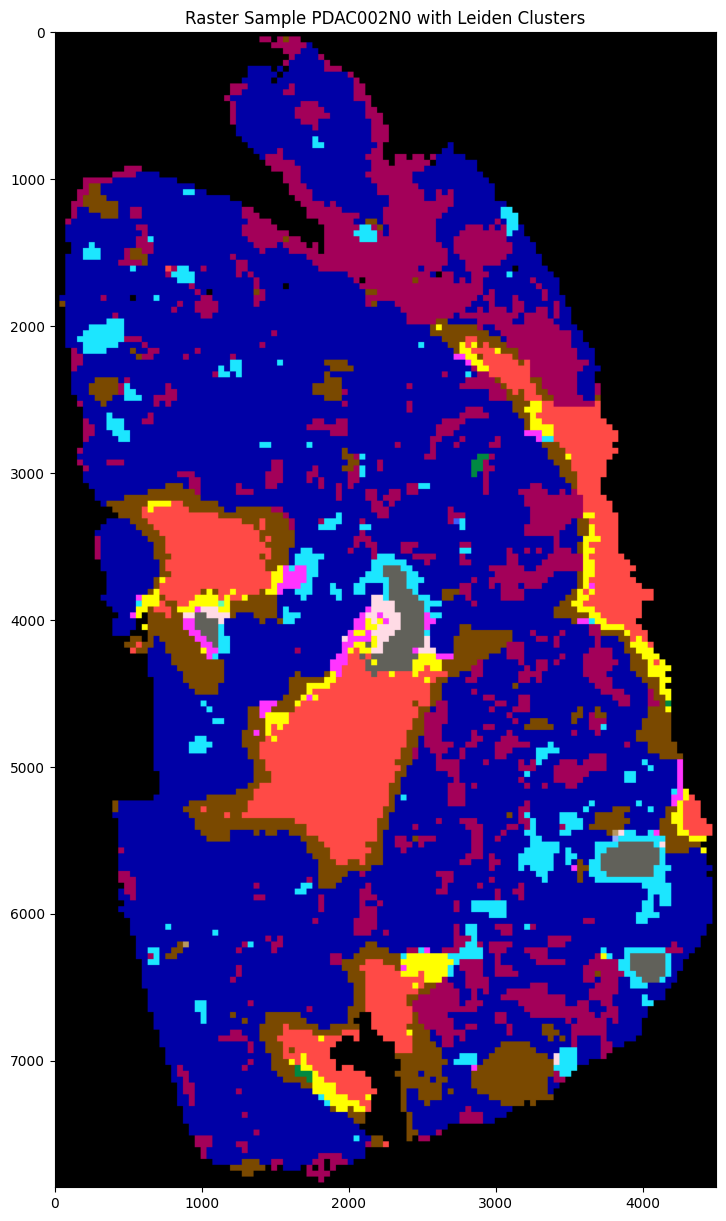

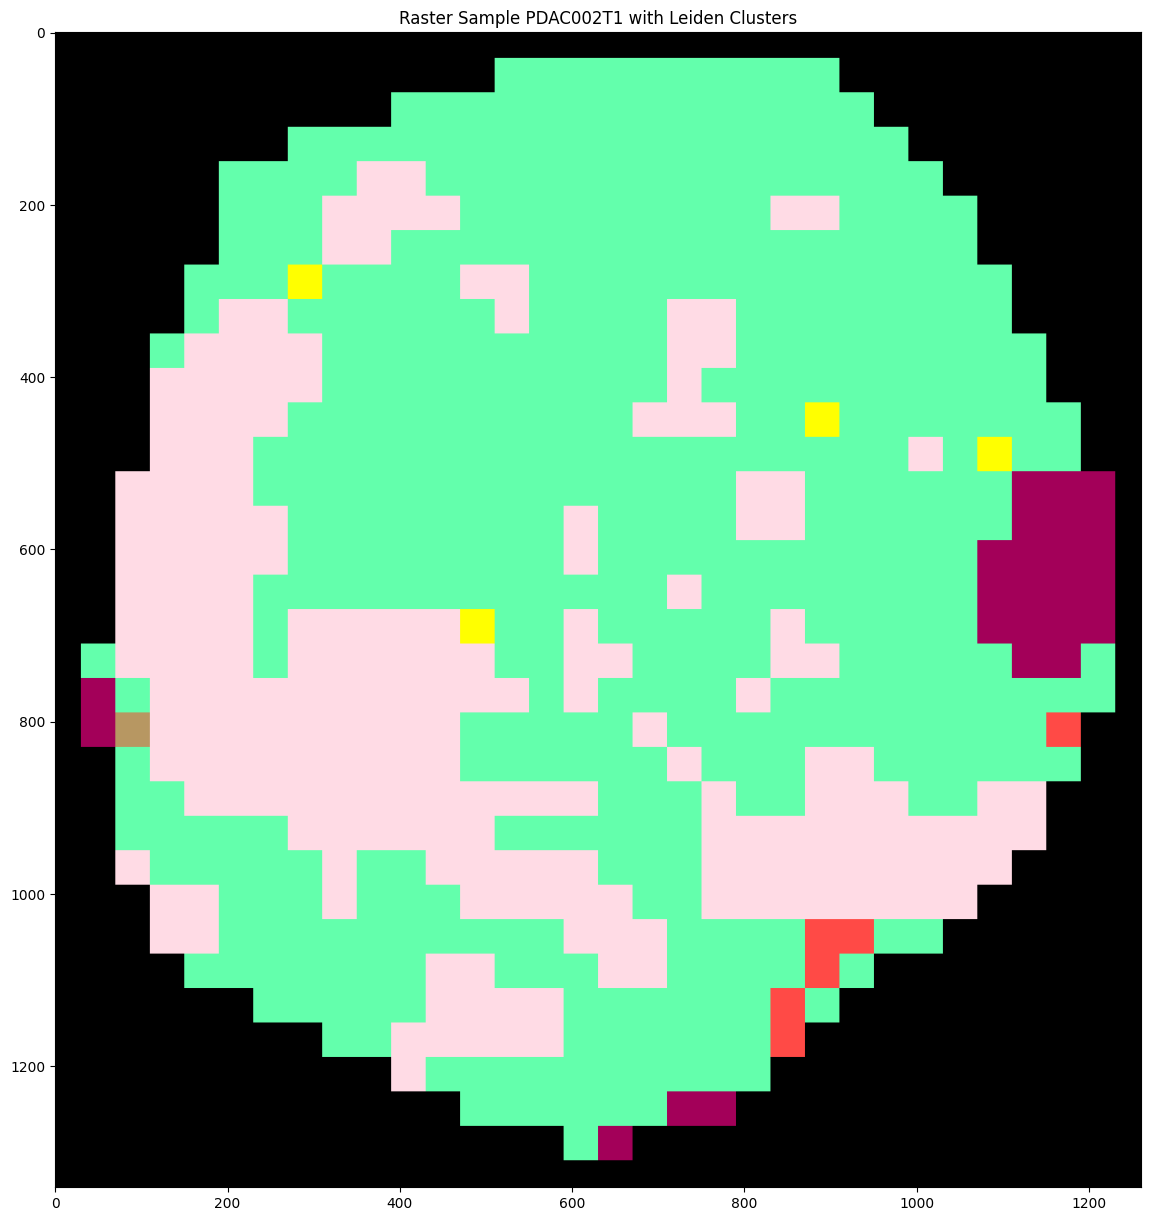

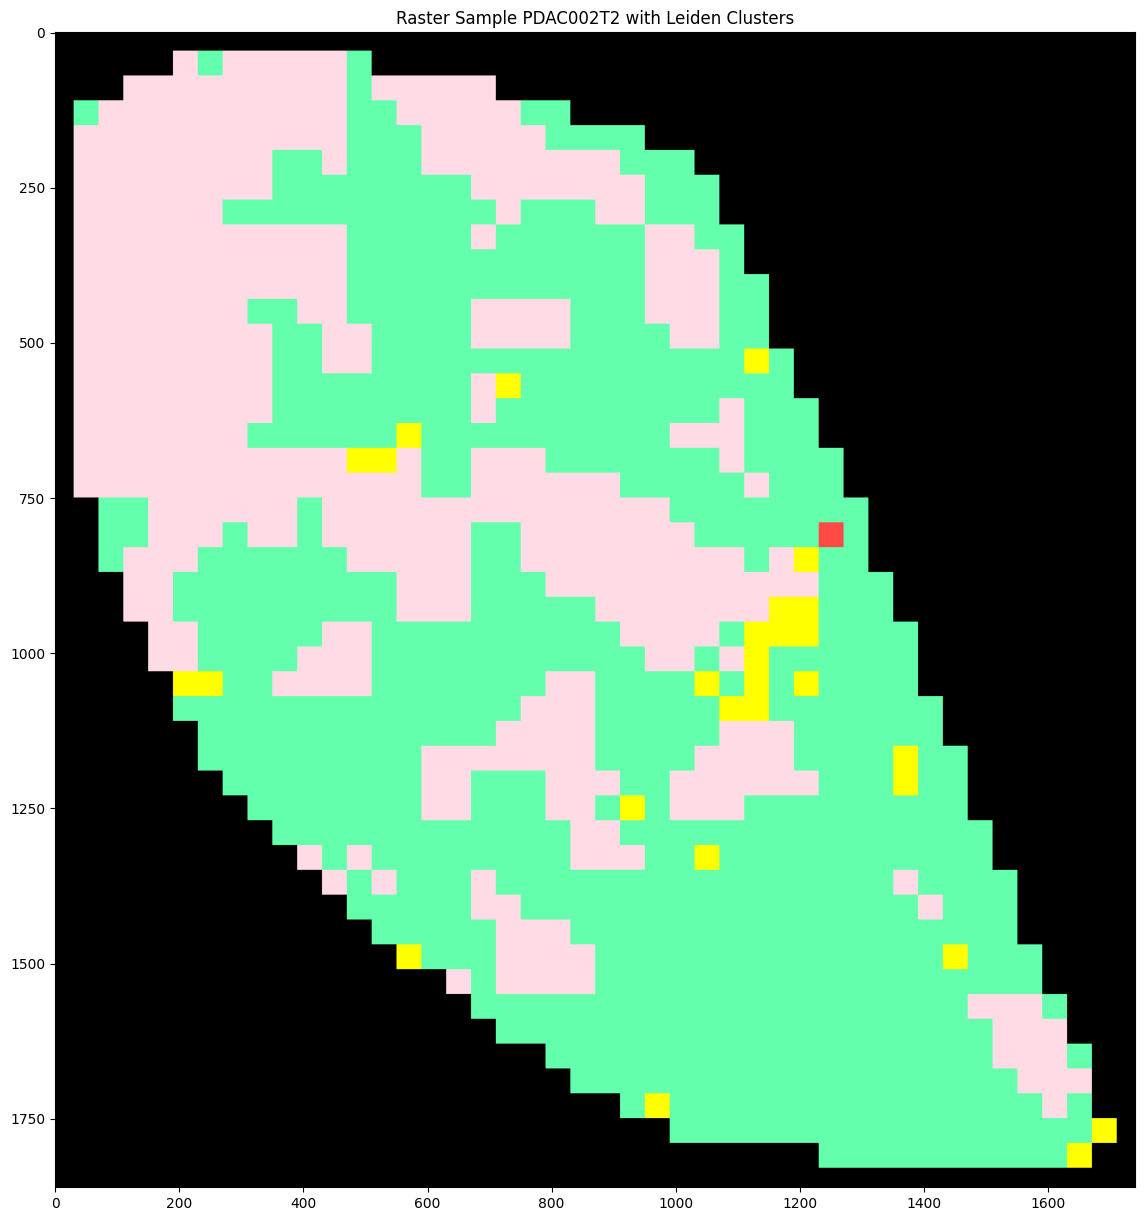

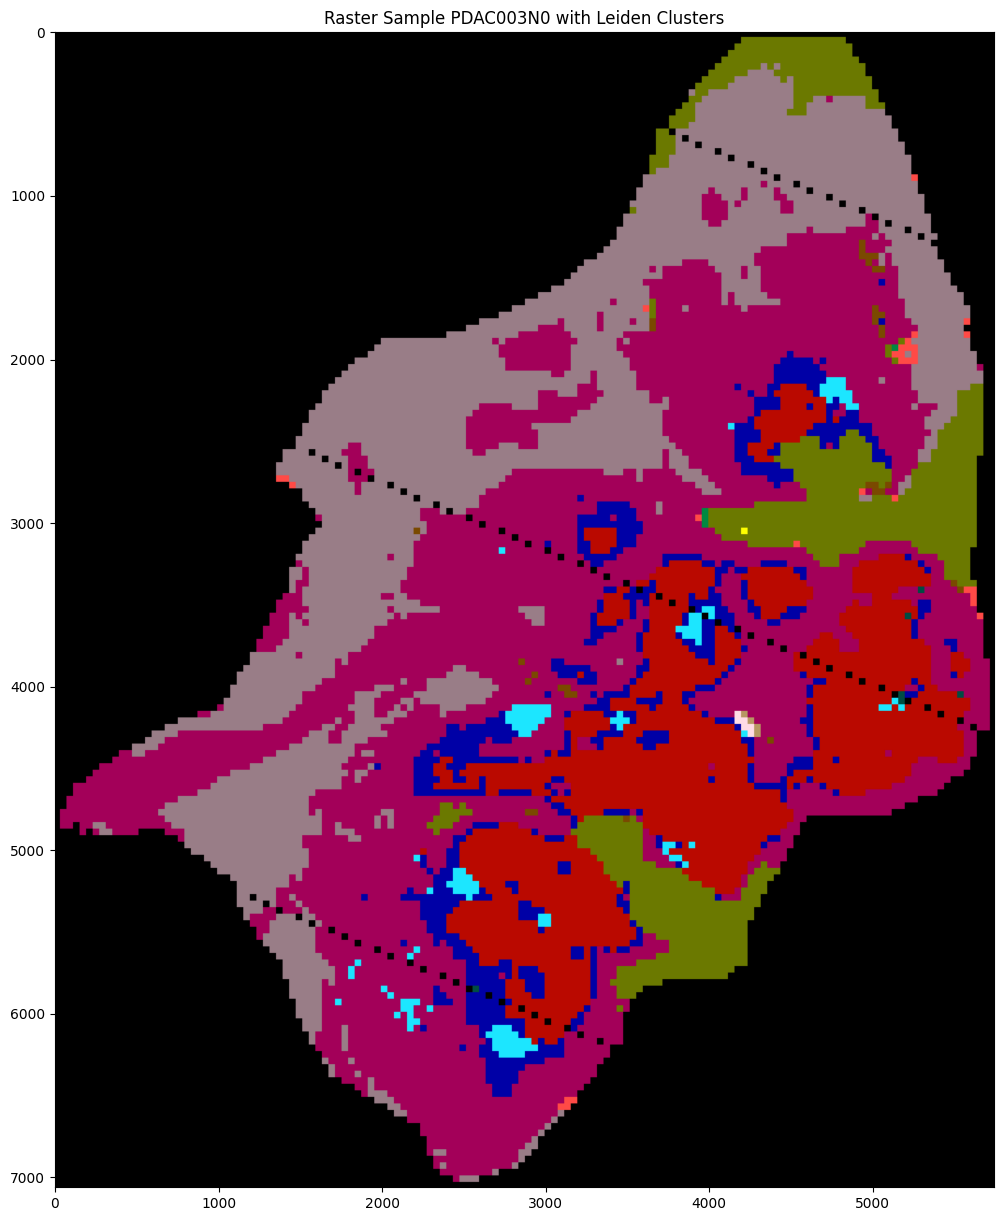

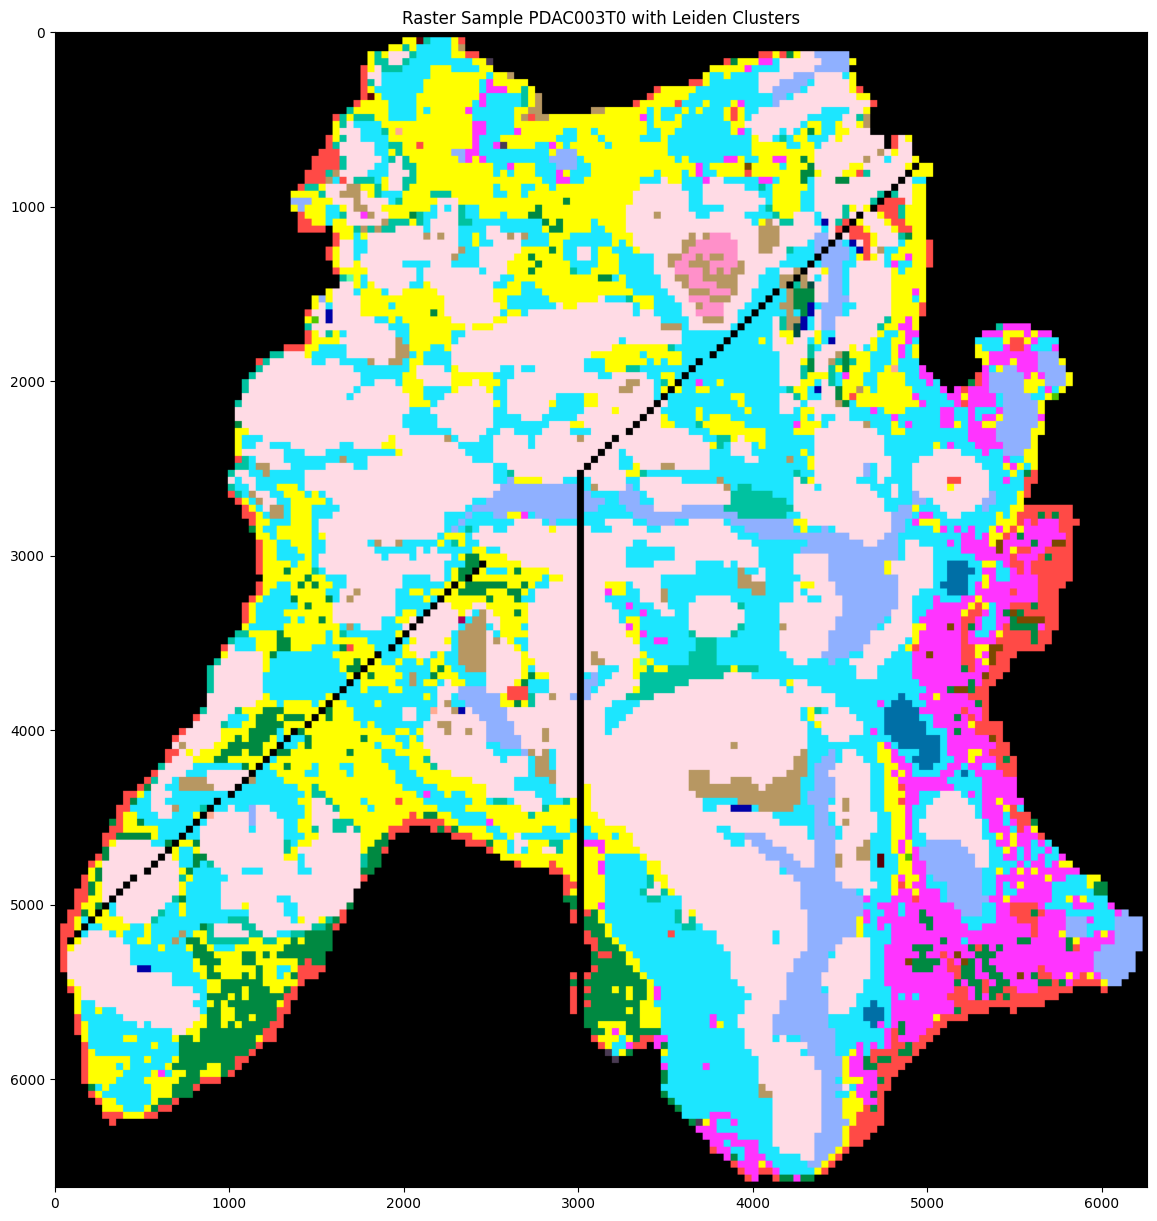

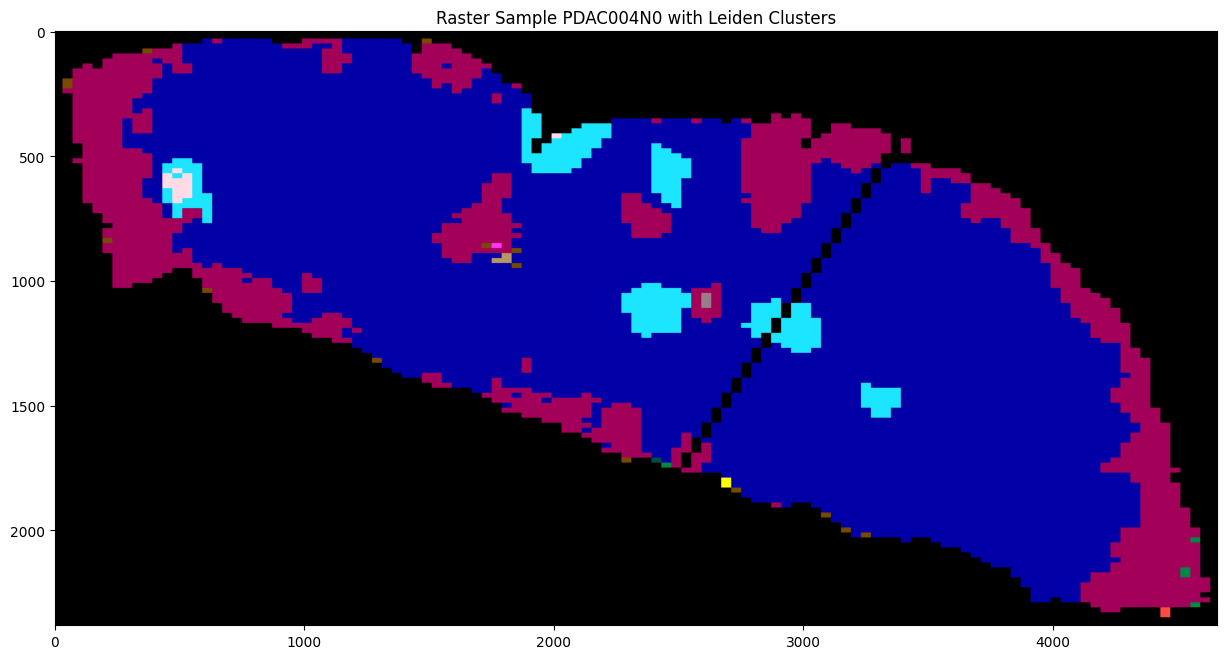

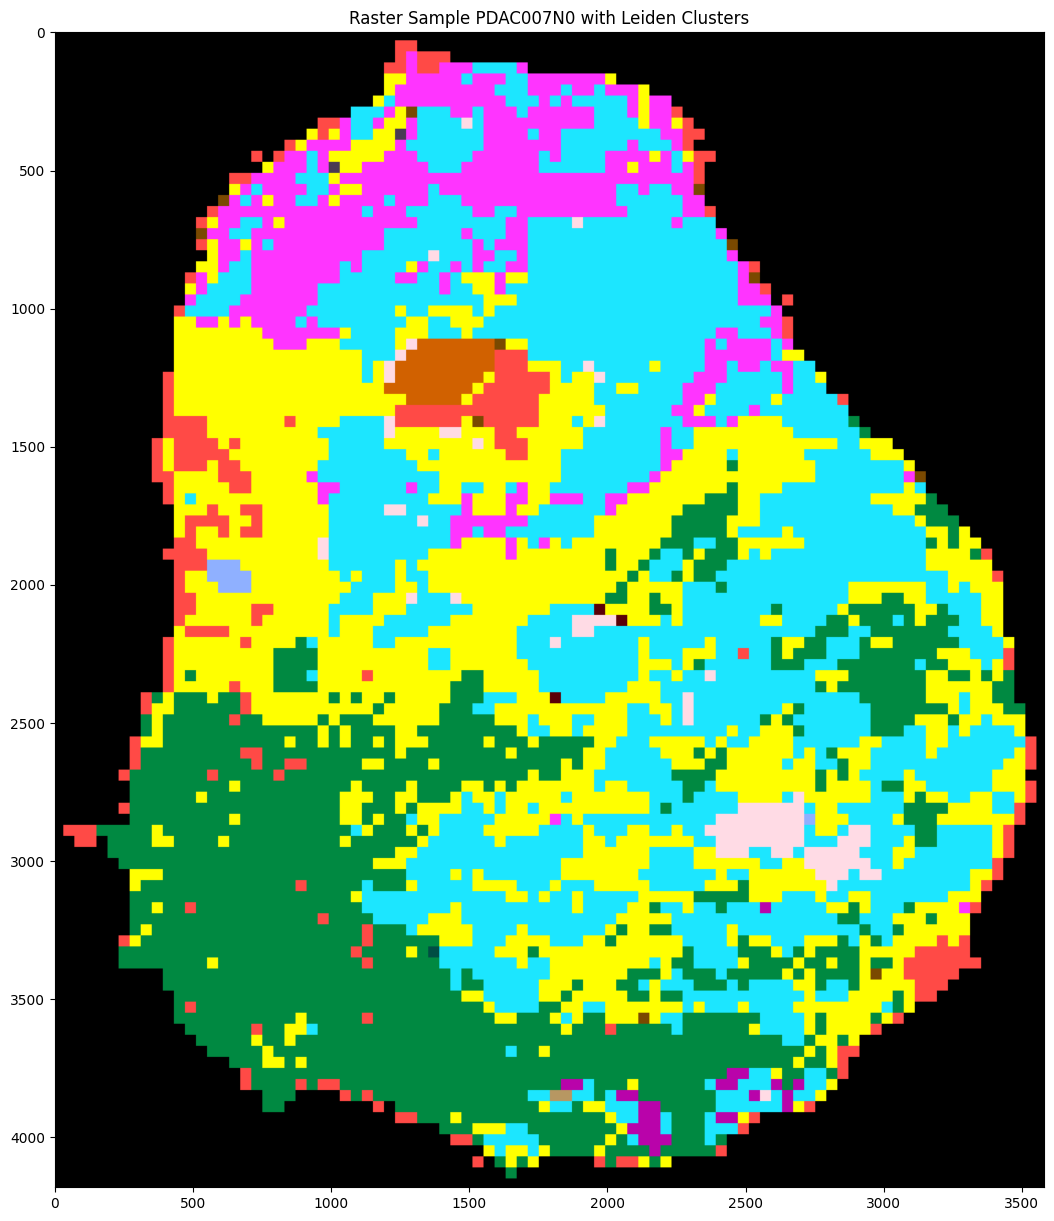

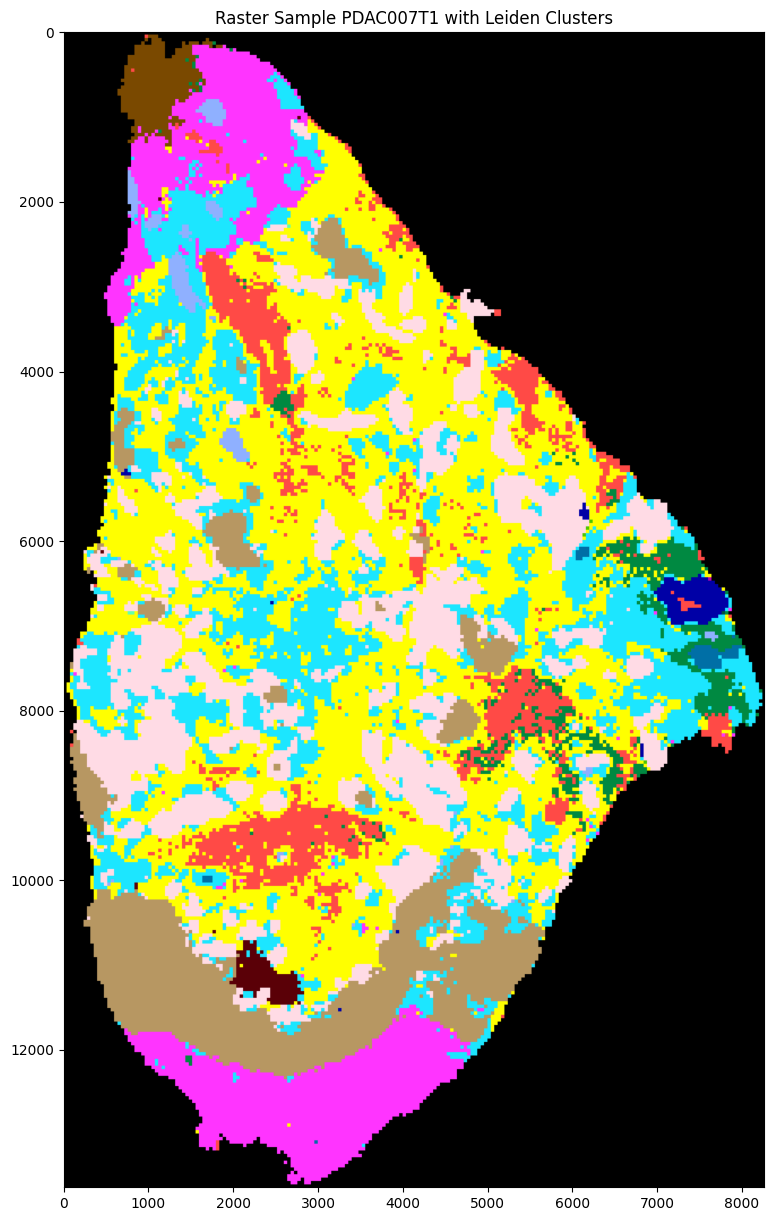

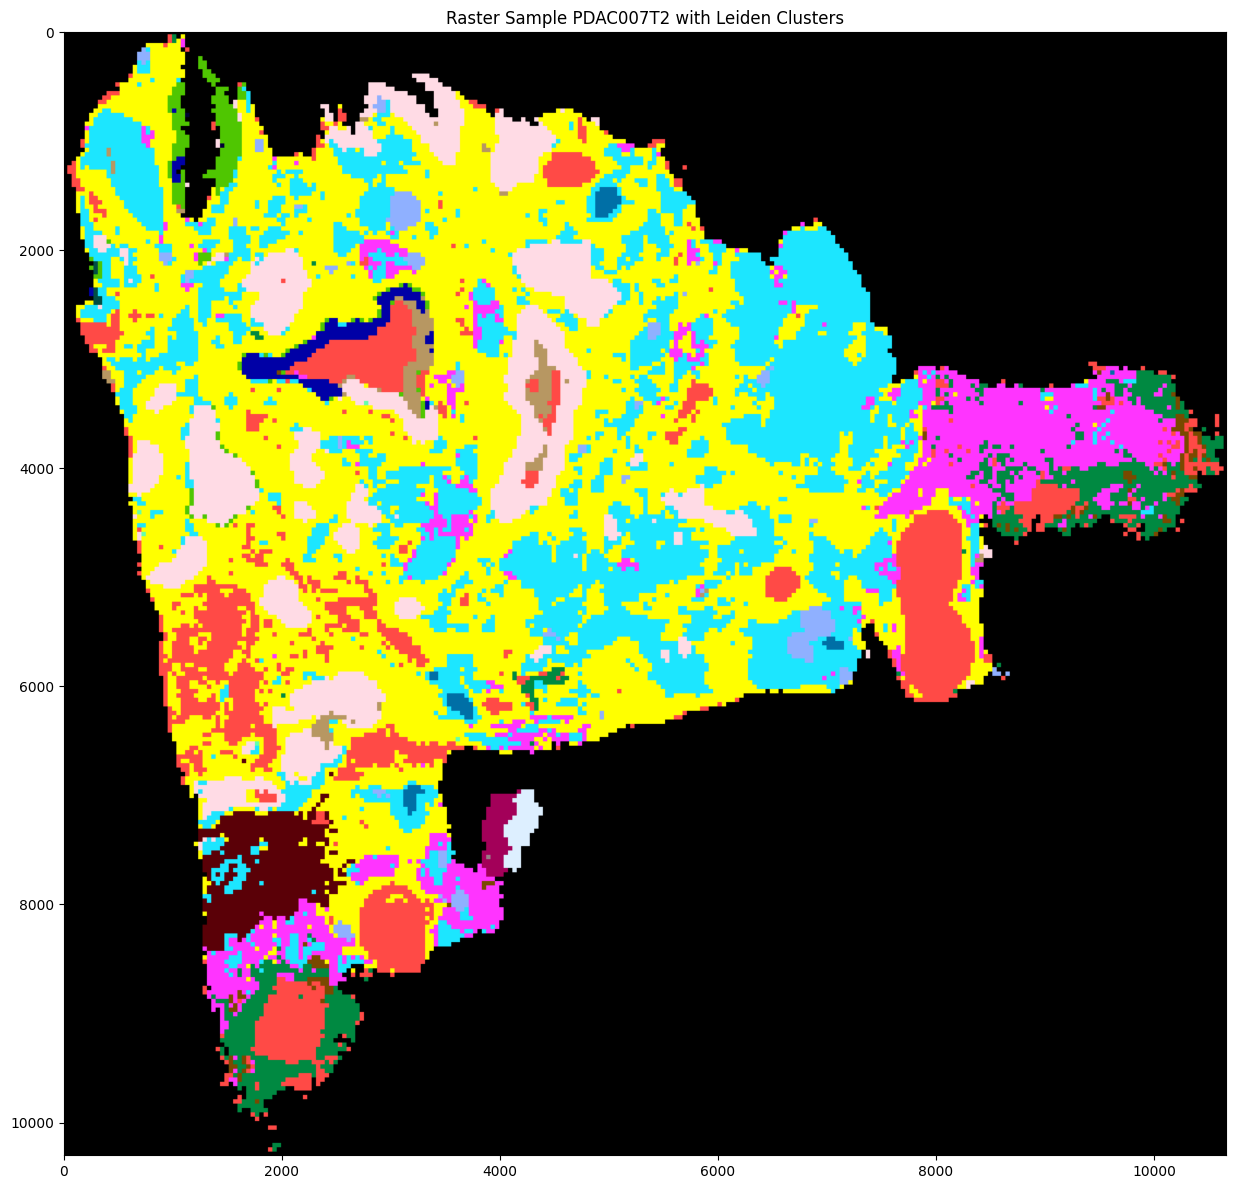

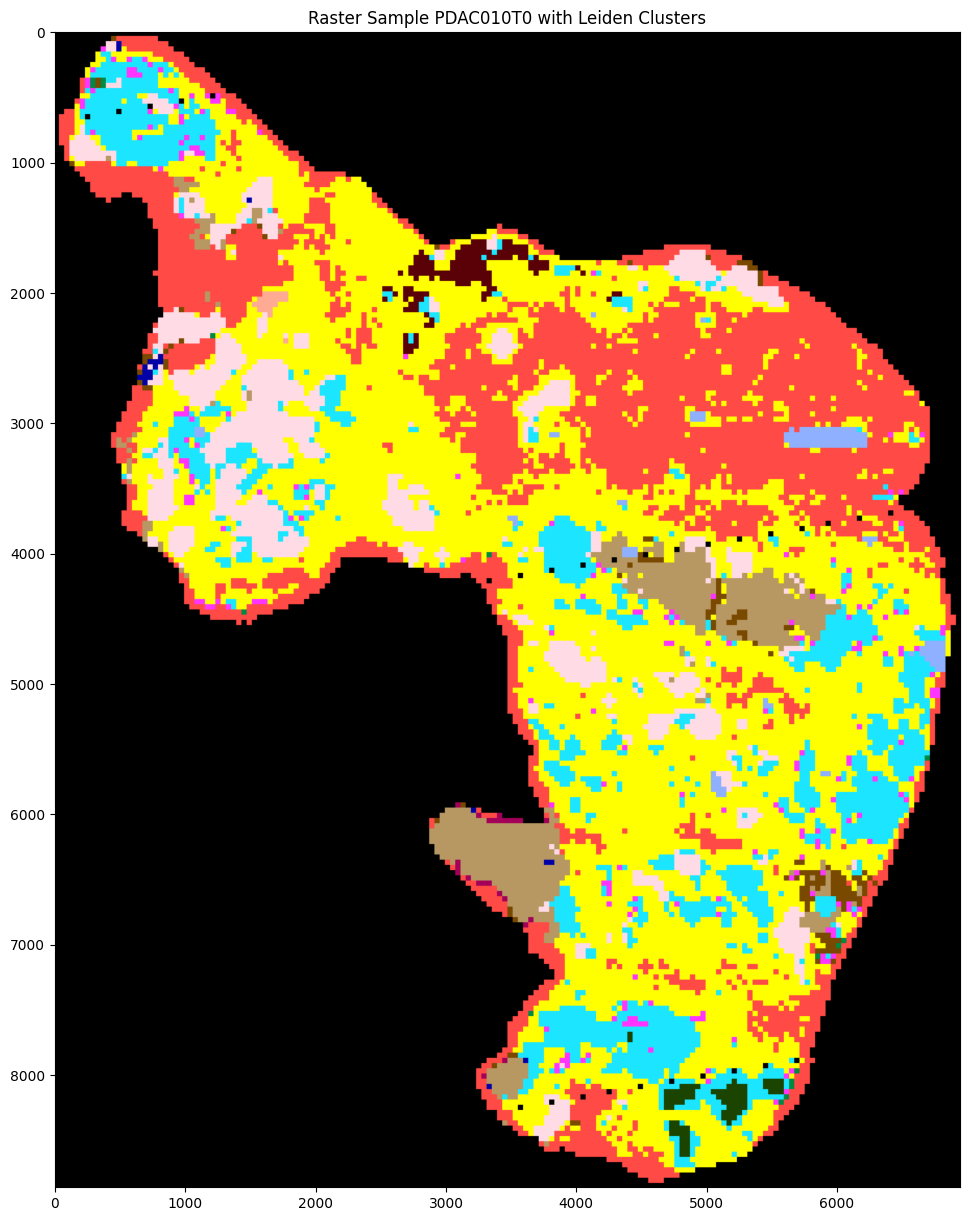

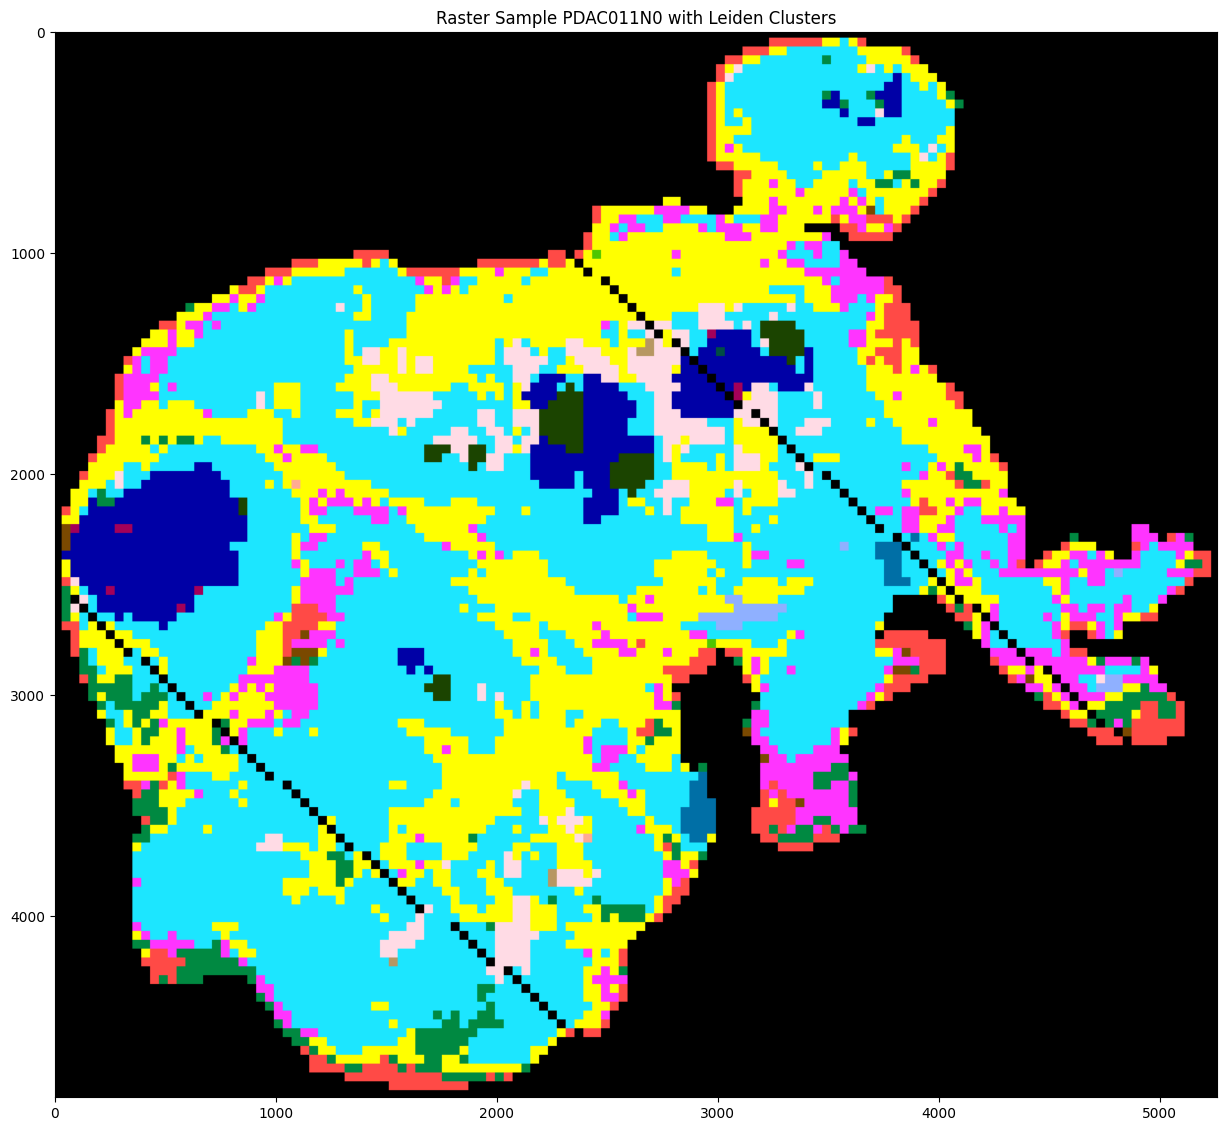

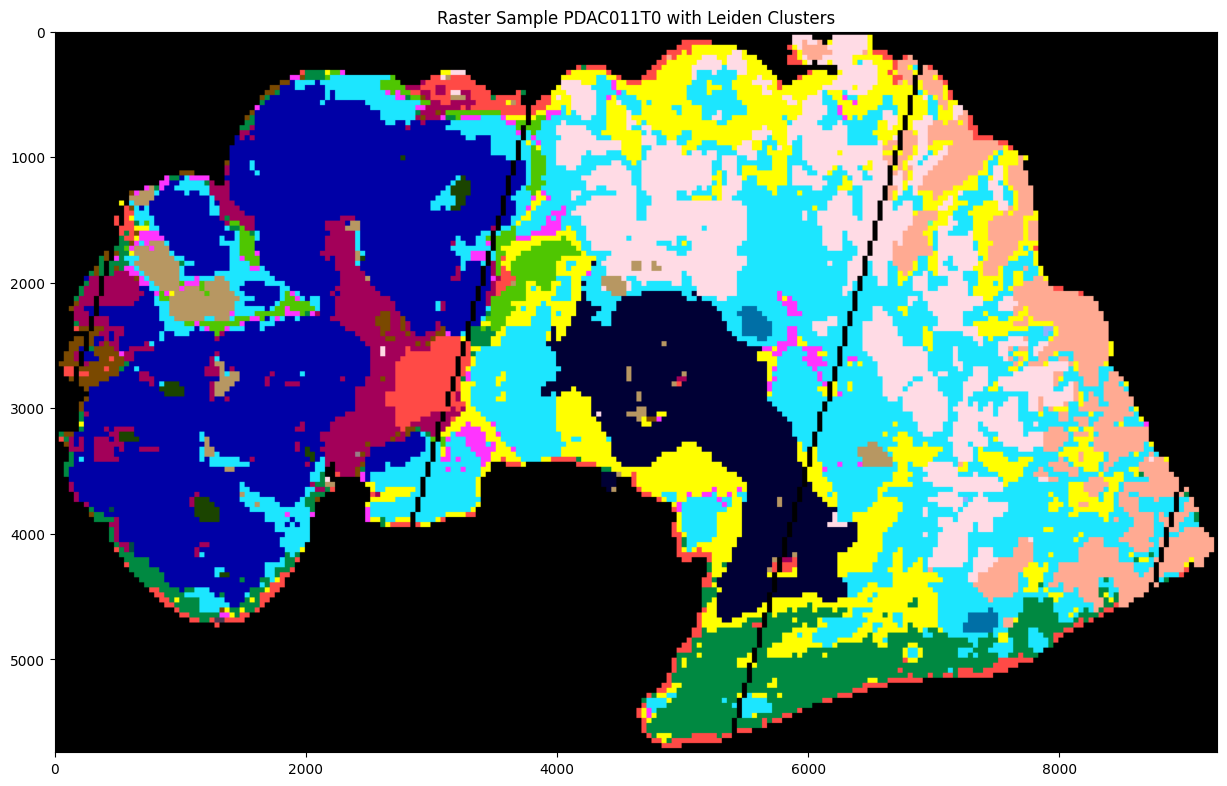

In [31]:
for sample_id in msi_dataset.obs['batch_id'].unique():
    visualize_spatial(
        clusters=msi_dataset[msi_dataset.obs['batch_id'] == sample_id].obs['leiden'].to_numpy(),
        raster_coords=msi_dataset[msi_dataset.obs['batch_id'] == sample_id].obsm['raster_coordinates'],
        cluster_colors=msi_dataset.uns['leiden_colors'],
        title=f"Raster Sample {sample_id} with Leiden Clusters"
    )